In [1]:
import pandas as pd

df = pd.read_csv("/content/spectra_441.csv")

# Pivot thành phổ
spectra_df = df.pivot_table(
    index=["h2", "p"],
    columns="wavelength",
    values="abs"
)

spectra_df = spectra_df.sort_index(axis=1)

print("Số phổ:", spectra_df.shape[0])
print("Số điểm mỗi phổ:", spectra_df.shape[1])

Số phổ: 441
Số điểm mỗi phổ: 1001


In [2]:
X = spectra_df.index.to_frame().values
y = spectra_df.values

print("Input shape:", X.shape)
print("Output shape:", y.shape)


Input shape: (441, 2)
Output shape: (441, 1001)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [9]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor

models = {
    # "RandomForest": RandomForestRegressor(
    #     n_estimators=200,
    #     random_state=42,
    #     n_jobs=-1
    # ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    # "DecisionTree": DecisionTreeRegressor(
    #     random_state=42
    # ),

    # "SVR": MultiOutputRegressor(
    #     SVR(
    #         kernel="rbf",
    #         C=100,
    #         gamma="scale",
    #         epsilon=0.01
    #     )
    # ),

    "XGBoost": MultiOutputRegressor(
        XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
}

In [10]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

trained_models = {}
results = {}

for name, model in models.items():

    print(f"Training {name}...")

    # ===== train =====
    model.fit(X_train, y_train)

    # ===== predict =====
    y_pred = model.predict(X_test)

    # ===== tính R2 =====
    r2 = r2_score(y_test, y_pred)

    # ===== RMSE =====
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # ===== lưu model =====
    trained_models[name] = model

    results[name] = {
        "R2": r2,
        "RMSE": rmse
    }

    print(f"{name}")
    print(f"R2   = {r2:.4f} ({r2*100:.2f}%)")
    print(f"RMSE = {rmse:.6f}")
    print("-"*40)

Training ExtraTrees...
ExtraTrees
R2   = 0.9935 (99.35%)
RMSE = 0.005419
----------------------------------------
Training XGBoost...
XGBoost
R2   = 0.9535 (95.35%)
RMSE = 0.011710
----------------------------------------


**New spectrum prediction**

Using model: ExtraTrees
Saved: ExtraTrees_spectrum_h2_0.2275_p_1.43.csv
R2 = 1.0000 (100.00%)


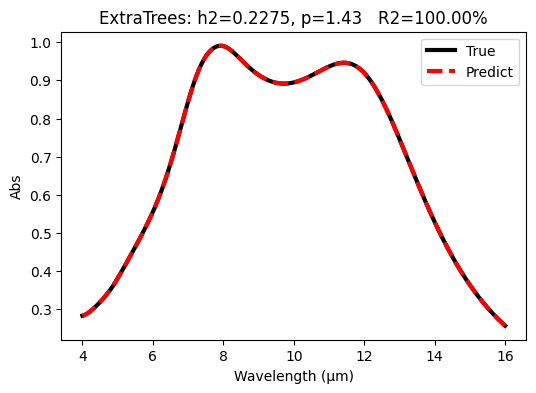

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ===== chọn model =====
model_name = "ExtraTrees"
model = trained_models[model_name]

print(f"Using model: {model_name}")

# ===== enter new value =====
h2_new = 0.2275
p_new  = 1.43

X_new = np.array([[h2_new, p_new]])

y_pred = model.predict(X_new)[0]
wavelengths_um = spectra_df.columns.astype(float) / 1000

# ===== lưu phổ dự đoán =====
df_pred = pd.DataFrame({
    "Wavelength_um": wavelengths_um,
    "Abs": y_pred
})

filename = f"{model_name}_spectrum_h2_{h2_new}_p_{p_new}.csv"
df_pred.to_csv(filename, index=False)

print("Saved:", filename)

# ===== đọc phổ thật từ CSV =====
true_file = "/content/h2 = 0.2275, p = 1.43.csv"

df_true = pd.read_csv(true_file)
y_true = df_true.iloc[:, 1].values

if len(y_true) != len(y_pred):
    print("Warning: y_true and y_pred have different lengths.")
    min_len = min(len(y_true), len(y_pred))
    y_true_matched = y_true[:min_len]
    y_pred_matched = y_pred[:min_len]
    plot_wavelengths = wavelengths_um[:min_len]
    r2 = r2_score(y_true_matched, y_pred_matched)
else:
    y_true_matched = y_true
    y_pred_matched = y_pred
    plot_wavelengths = wavelengths_um
    r2 = r2_score(y_true, y_pred)

print(f"R2 = {r2:.4f} ({r2*100:.2f}%)")

plt.figure(figsize=(6,4))
plt.plot(plot_wavelengths, y_true_matched,
         color="black",
         linewidth=3,
         label="True")

plt.plot(plot_wavelengths, y_pred_matched,
         "--",
         color="red",
         linewidth=3,
         label="Predict")

plt.xlabel("Wavelength (µm)")
plt.ylabel("Abs")
plt.title(f"{model_name}: h2={h2_new}, p={p_new}   R2={r2*100:.2f}%")

plt.legend()
plt.show()

**Predict 100 new spectra to use as input for the inverse prediction model.**

In [ ]:
import numpy as np
import pandas as pd
import os

# ===== tạo thư mục riêng =====
output_dir = "/content/spectra_LHS_100"
os.makedirs(output_dir, exist_ok=True)

# ===== số điểm =====
N = 100

h1_min, h1_max = 0.22, 0.32
p1_min, p1_max = 1.4, 1.8

h1_edges = np.linspace(h1_min, h1_max, N + 1)
p1_edges = np.linspace(p1_min, p1_max, N + 1)

# ===== sinh LHS =====
h1_samples = [np.random.uniform(h1_edges[i], h1_edges[i+1]) for i in range(N)]
p1_samples = [np.random.uniform(p1_edges[i], p1_edges[i+1]) for i in range(N)]

np.random.shuffle(p1_samples)

new_points = list(zip(h1_samples, p1_samples))
X_new = np.array(new_points)

# ===== predict =====
Y_new = model.predict(X_new)

# ===== wavelength =====
wavelengths_um = spectra_df.columns.astype(float) / 1000

# ===== lưu file (không trùng tên) =====
for i, (h1, p1) in enumerate(new_points):

    base_name = f"spectrum_h1_{round(h1,4)}_p1_{round(p1,4)}.csv"
    filepath = os.path.join(output_dir, base_name)

    # ===== nếu trùng tên thì thêm index =====
    count = 1
    while os.path.exists(filepath):
        filepath = os.path.join(
            output_dir,
            f"spectrum_{count}_h1_{round(h1,4)}_p1_{round(p1,4)}.csv"
        )
        count += 1

    df = pd.DataFrame({
        "Wavelength_um": wavelengths_um,
        "Abs": Y_new[i]
    })

    df.to_csv(filepath, index=False)

print("Done! Saved to:", output_dir)

Done! Saved to: /content/spectra_LHS_100
